In [ ]:
!pip install -q kagglehub opencv-python seaborn

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
path = kagglehub.dataset_download("hasyimabdillah/workoutfitness-video")
print("Dataset Path:", path)

100%|██████████| 4.32G/4.32G [01:00<00:00, 76.7MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


In [ ]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

Folder: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5
Subfolders: ['hip thrust', 'incline bench press', 'tricep dips', 'barbell biceps curl', 'squat']
Files: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5/hip thrust
Subfolders: []
Files: ['hip thrust_9.mp4', 'hip thrust_1.MOV', 'hip thrust_7.mp4', 'hip thrust_5.mp4', 'hip thrust_11.mp4']
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5/incline bench press
Subfolders: []
Files: ['incline bench press_23.mp4', 'incline bench press_13.mp4', 'incline bench press_20.mp4', 'incline bench press_2.mp4', 'incline bench press_10.mp4']
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5/tricep dips
Subfolders: []
Files: ['tricep dips_6.mp4', 'tricep d

In [ ]:
video_data = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.mp4','.avi','.mov','.mkv')):
            full_path = os.path.join(root,file)
            label = os.path.basename(root)

            try:
                size_mb = os.path.getsize(full_path)/(1024*1024)

                cap = cv2.VideoCapture(full_path)
                frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                fps = cap.get(cv2.CAP_PROP_FPS)
                width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                duration = frames/fps if fps > 0 else 0
                cap.release()

                video_data.append({
                    "label": label,
                    "filename": file,
                    "size_mb": size_mb,
                    "frames": frames,
                    "fps": fps,
                    "width": width,
                    "height": height,
                    "duration_sec": duration
                })
            except:
                pass

df = pd.DataFrame(video_data)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (592, 8)


,label,filename,size_mb,frames,fps,width,height,duration_sec
0,hip thrust,hip thrust_9.mp4,8.909136,389,29.970030,1280,720,12.979633
1,hip thrust,hip thrust_7.mp4,6.757412,299,29.970030,1280,720,9.976633
2,hip thrust,hip thrust_5.mp4,21.923978,1012,24.000000,1280,720,42.166667
3,hip thrust,hip thrust_11.mp4,2.139524,105,29.970030,1280,720,3.503500
4,hip thrust,hip thrust_6.mp4,3.265420,113,23.976024,1280,720,4.713042


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   label         592 non-null    object 
 1   filename      592 non-null    object 
 2   size_mb       592 non-null    float64
 3   frames        592 non-null    int64  
 4   fps           592 non-null    float64
 5   width         592 non-null    int64  
 6   height        592 non-null    int64  
 7   duration_sec  592 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 37.1+ KB
None
          size_mb       frames         fps        width       height  \
count  592.000000   592.000000  592.000000   592.000000   592.000000   
mean     3.443830   196.645270   28.427315  1544.891892   870.239865   
std      5.638608   335.351253    3.174647   335.841094   191.129203   
min      0.122302    30.000000   23.976024   320.000000   240.000000   
25%      0.408879    78.000000   25.00

label           0
filename        0
size_mb         0
frames          0
fps             0
width           0
height          0
duration_sec    0
dtype: int64


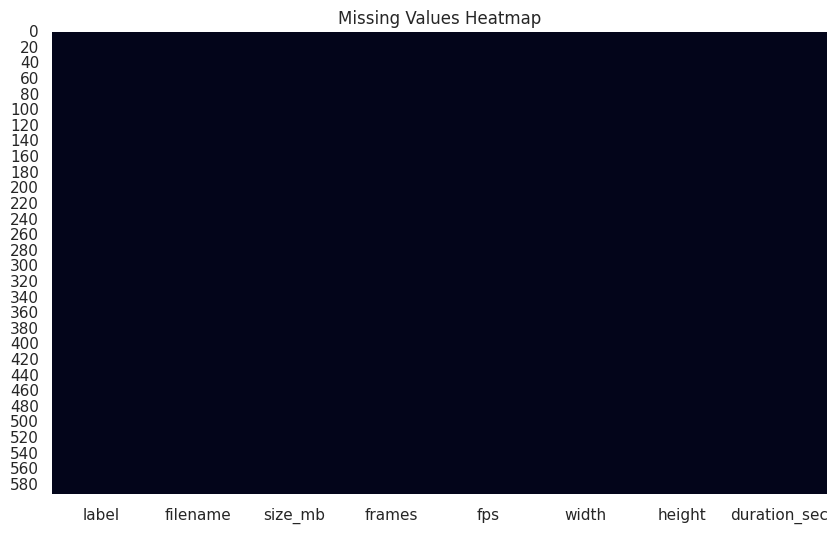

In [ ]:
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

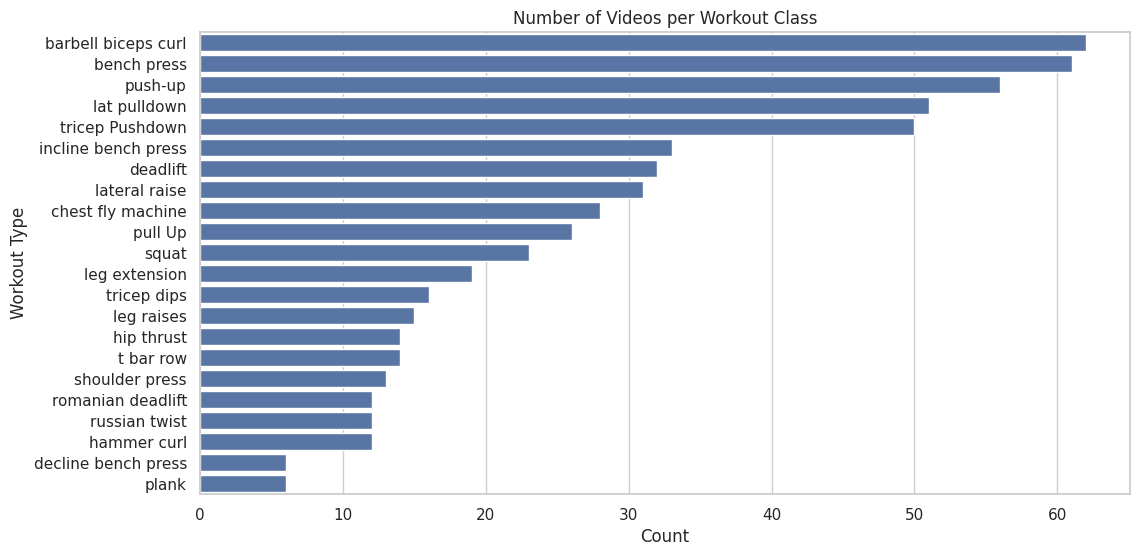

label
barbell biceps curl    62
bench press            61
push-up                56
lat pulldown           51
tricep Pushdown        50
incline bench press    33
deadlift               32
lateral raise          31
chest fly machine      28
pull Up                26
squat                  23
leg extension          19
tricep dips            16
leg raises             15
hip thrust             14
t bar row              14
shoulder press         13
romanian deadlift      12
russian twist          12
hammer curl            12
decline bench press     6
plank                   6
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y=df["label"], order=df["label"].value_counts().index)
plt.title("Number of Videos per Workout Class")
plt.xlabel("Count")
plt.ylabel("Workout Type")
plt.show()

print(df["label"].value_counts())

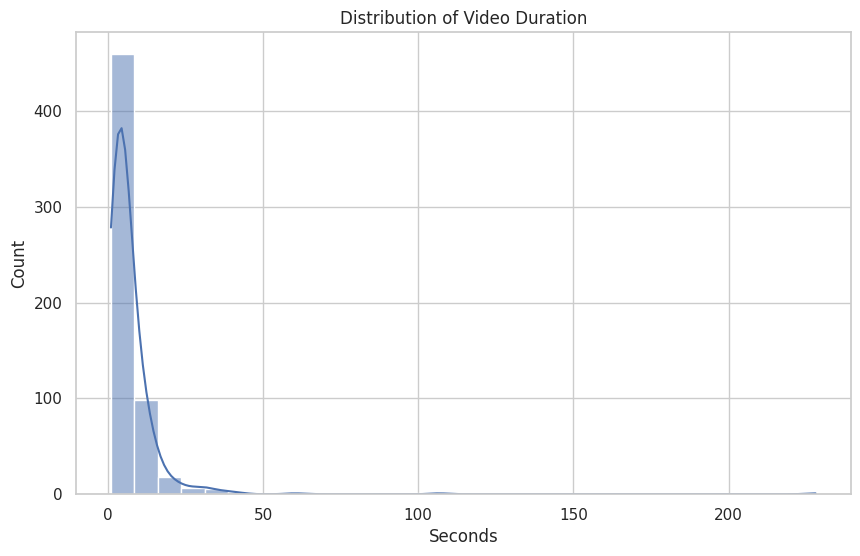

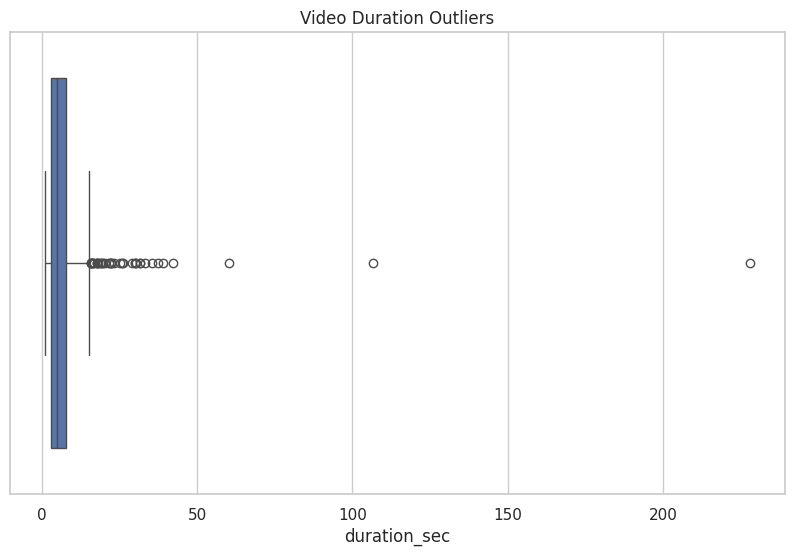

In [ ]:
sns.histplot(df["duration_sec"], bins=30, kde=True)
plt.title("Distribution of Video Duration")
plt.xlabel("Seconds")
plt.show()

sns.boxplot(x=df["duration_sec"])
plt.title("Video Duration Outliers")
plt.show()

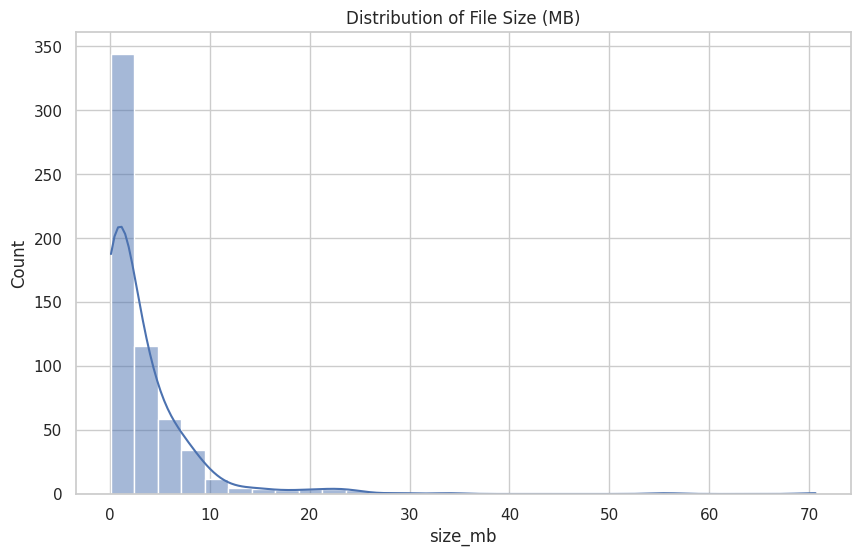

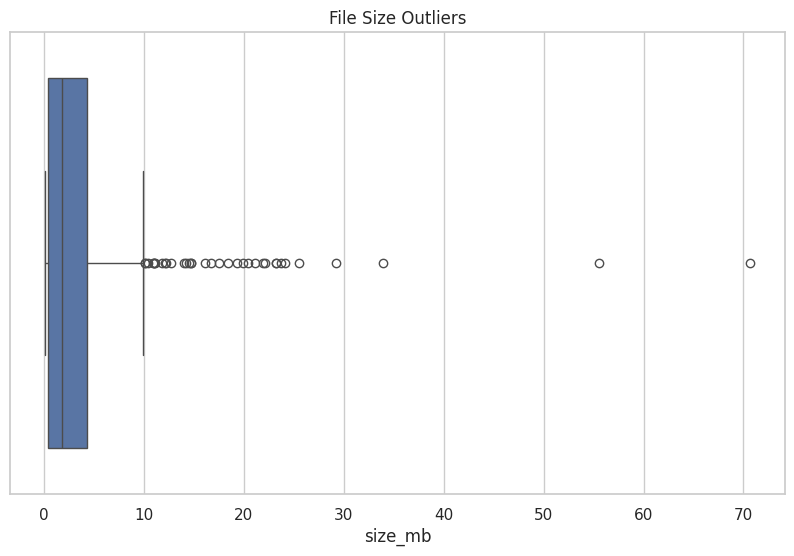

In [ ]:
sns.histplot(df["size_mb"], bins=30, kde=True)
plt.title("Distribution of File Size (MB)")
plt.show()

sns.boxplot(x=df["size_mb"])
plt.title("File Size Outliers")
plt.show()

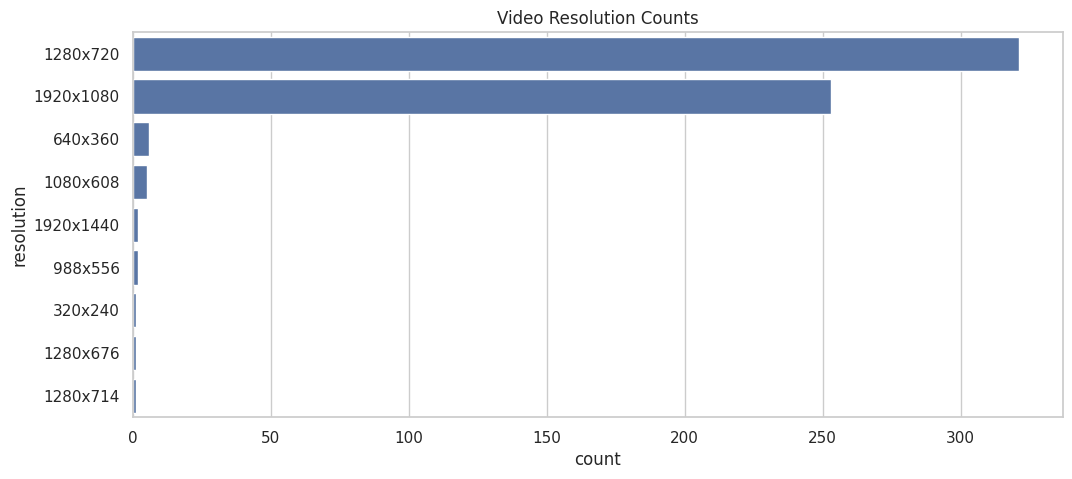

In [ ]:
df["resolution"] = df["width"].astype(str) + "x" + df["height"].astype(str)

plt.figure(figsize=(12,5))
sns.countplot(y=df["resolution"], order=df["resolution"].value_counts().index)
plt.title("Video Resolution Counts")
plt.show()

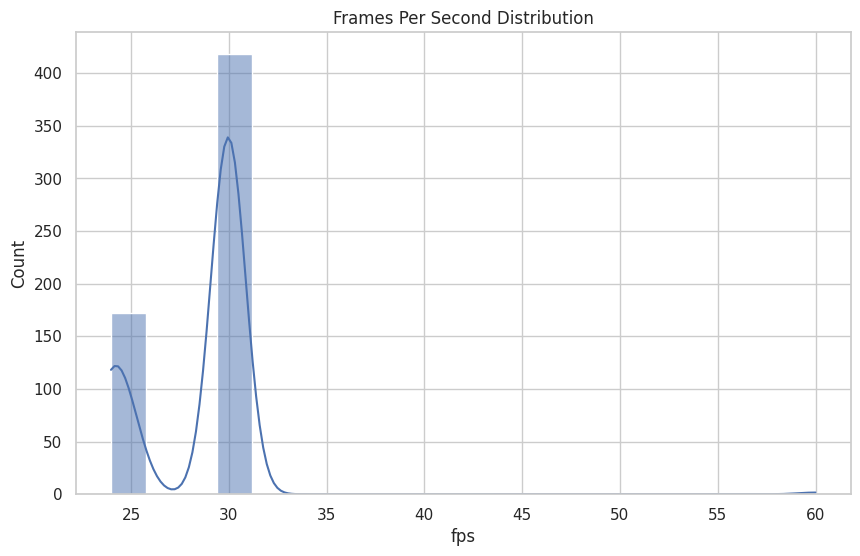

In [ ]:
sns.histplot(df["fps"], bins=20, kde=True)
plt.title("Frames Per Second Distribution")
plt.show()


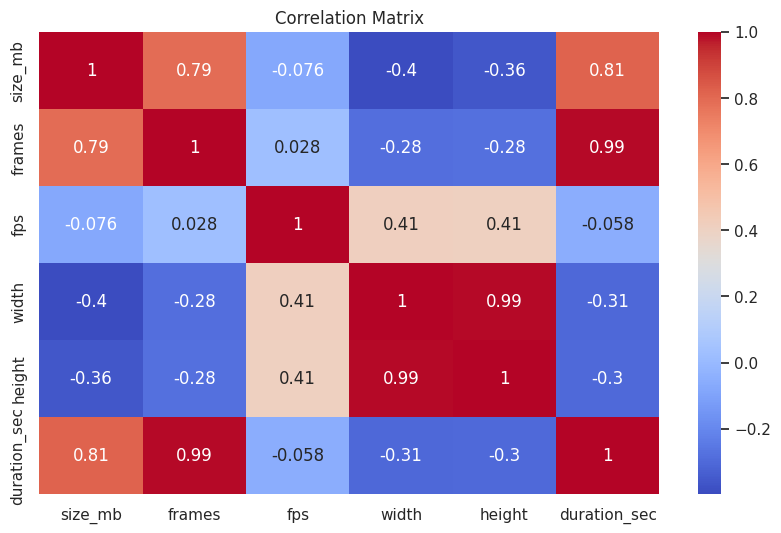

In [ ]:
numeric_cols = ["size_mb","frames","fps","width","height","duration_sec"]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Sample Frame Viz.

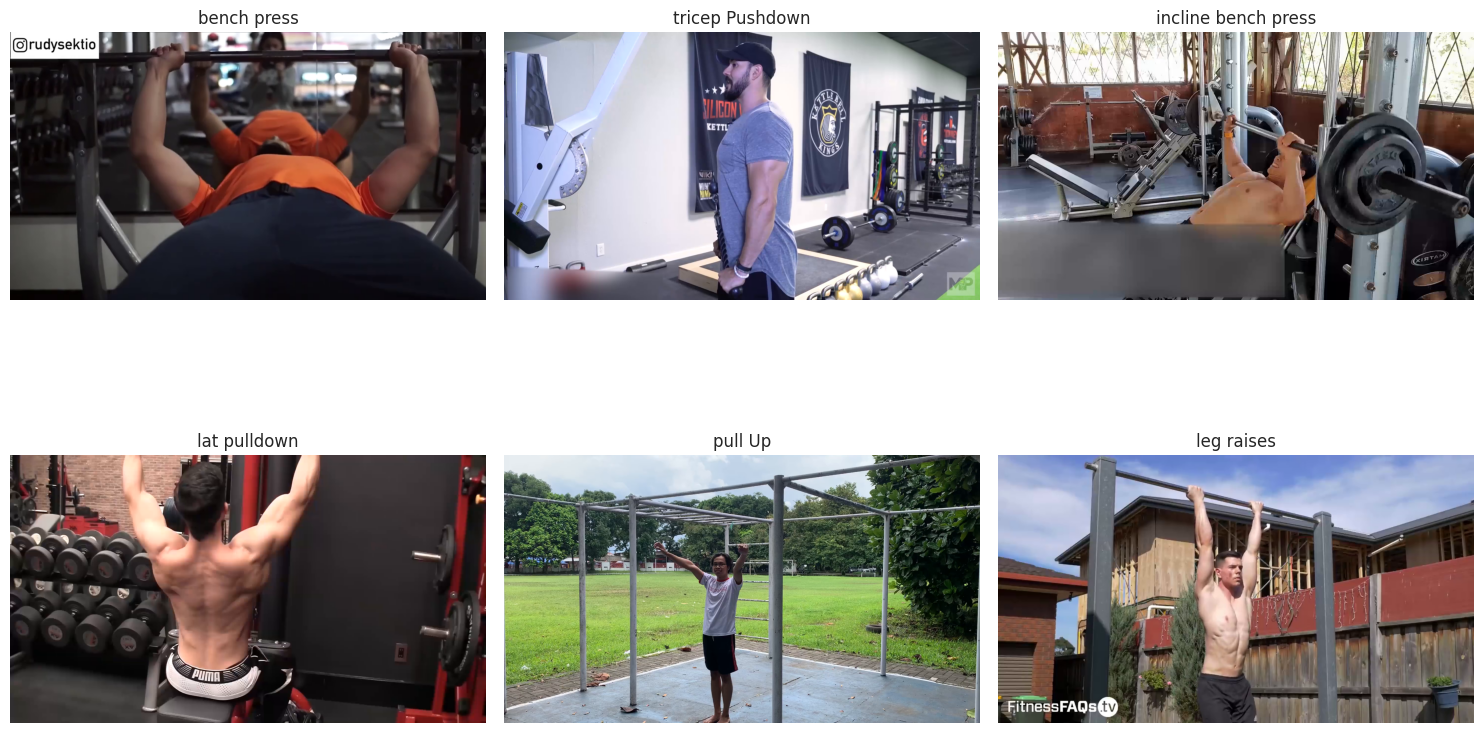

In [ ]:
sample_files = df.sample(min(6,len(df)))

plt.figure(figsize=(15,10))

for i, row in enumerate(sample_files.itertuples()):
    cap = cv2.VideoCapture(os.path.join(path, row.label, row.filename))
    success, frame = cap.read()
    cap.release()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(2,3,i+1)
        plt.imshow(frame)
        plt.title(row.label)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Duplicate filenames:", df["filename"].duplicated().sum())

Duplicate filenames: 0


No duplicates


In [ ]:
print("Number of Workout Classes:", df["label"].nunique())
print("Total Videos:", len(df))
print("Average Duration:", round(df["duration_sec"].mean(),2),"sec")
print("Average File Size:", round(df["size_mb"].mean(),2),"MB")
print("Most Common Class:")
print(df["label"].value_counts().head(1))

Number of Workout Classes: 22
Total Videos: 592
Average Duration: 6.99 sec
Average File Size: 3.44 MB
Most Common Class:
label
barbell biceps curl    62
Name: count, dtype: int64


Total Videos Checked: 592
Valid Videos: 592
Corrupted Videos: 0


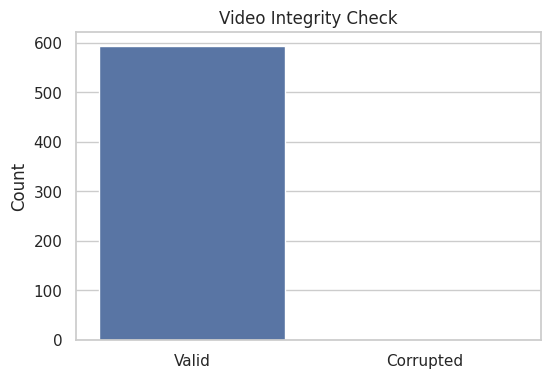

In [ ]:
# ============================================
# CORRUPTED VIDEO CHECK
# Add this section after loading dataset
# ============================================

corrupted_videos = []
valid_videos = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.mp4', '.avi', '.mov', '.mkv')):
            full_path = os.path.join(root, file)

            try:
                cap = cv2.VideoCapture(full_path)

                # Try reading first frame
                success, frame = cap.read()

                # Extract metadata
                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                fps = cap.get(cv2.CAP_PROP_FPS)

                cap.release()

                # Conditions for corruption
                if (not success) or frame_count == 0 or fps == 0:
                    corrupted_videos.append(full_path)
                else:
                    valid_videos.append(full_path)

            except:
                corrupted_videos.append(full_path)

# Results
print("Total Videos Checked:", len(valid_videos) + len(corrupted_videos))
print("Valid Videos:", len(valid_videos))
print("Corrupted Videos:", len(corrupted_videos))

# Show corrupted files
if len(corrupted_videos) > 0:
    print("\nCorrupted Video Files:")
    for vid in corrupted_videos:
        print(vid)

# Optional Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=["Valid", "Corrupted"], y=[len(valid_videos), len(corrupted_videos)])
plt.title("Video Integrity Check")
plt.ylabel("Count")
plt.show()

In [3]:
!pip install -q ultralytics opencv-python scikit-learn kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00


In [4]:
import kagglehub
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import shutil
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
path = kagglehub.dataset_download("hasyimabdillah/workoutfitness-video")
print("Dataset Path:", path)

100%|██████████| 4.32G/4.32G [00:36<00:00, 126MB/s] 

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


In [6]:
IMG_SIZE = 640
FRAMES_PER_VIDEO = 8

output_dir = "/content/exercise_frames"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir, exist_ok=True)

video_extensions = ('.mp4','.avi','.mov','.mkv')

for label in os.listdir(path):
    label_path = os.path.join(path, label)

    if os.path.isdir(label_path):
        save_folder = os.path.join(output_dir, label)
        os.makedirs(save_folder, exist_ok=True)

        for file in os.listdir(label_path):
            if file.endswith(video_extensions):

                full_path = os.path.join(label_path, file)
                cap = cv2.VideoCapture(full_path)

                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

                if total_frames <= 0:
                    cap.release()
                    continue

                picks = np.linspace(
                    0,
                    total_frames - 1,
                    FRAMES_PER_VIDEO,
                    dtype=int
                )

                count = 0
                saved = 0

                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break

                    if count in picks:
                        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                        save_name = f"{file[:-4]}_{saved}.jpg"
                        cv2.imwrite(
                            os.path.join(save_folder, save_name),
                            frame
                        )
                        saved += 1

                    count += 1

                cap.release()

print("Frame extraction complete.")

Frame extraction complete.


In [7]:
base = "/content/yolo_exercise"

for split in ["train", "val"]:
    os.makedirs(f"{base}/{split}", exist_ok=True)

classes = sorted(os.listdir(output_dir))

for cls in classes:
    src = os.path.join(output_dir, cls)
    imgs = os.listdir(src)

    train_imgs, val_imgs = train_test_split(
        imgs,
        test_size=0.2,
        random_state=42
    )

    os.makedirs(f"{base}/train/{cls}", exist_ok=True)
    os.makedirs(f"{base}/val/{cls}", exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(src, img),
            f"{base}/train/{cls}/{img}"
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(src, img),
            f"{base}/val/{cls}/{img}"
        )

print("Train/Validation split complete.")


Train/Validation split complete.


In [8]:
model = YOLO("yolo11n-cls.pt")

In [9]:
results = model.train(
    data=base,
    epochs=20,
    imgsz=224,
    batch=32,
    device=0
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_exercise, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,554,206 parameters, 0 gradients, 3.2 GFLOPs
train: /content/yolo_exercise/train... found 3778 images in 22 classes ✅ 
val: /content/yolo_exercise/val... found 956 images in 22 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1773.2±655.5 MB/s, size: 113.0 KB)
val: Scanning /content/yolo_exercise/val... 956 images, 0 corrupt: 100% ━━━━━━━━━━━━ 956/956 160.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 60/60 9.1it/s 6.6s
                   all      0.998          1
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd2c22772f0>
curves: []
curves_results: []
fitness: 0.9989539682865143
keys: ['metric

In [11]:
sample_class = random.choice(classes)
sample_folder = os.path.join(base, "val", sample_class)
sample_img = os.path.join(sample_folder, random.choice(os.listdir(sample_folder)))

pred = model.predict(sample_img, imgsz=224)

print("Actual Class:", sample_class)
print("Prediction:", pred[0].probs.top1)


image 1/1 /content/yolo_exercise/val/lateral raise/lateral raise_8_5.jpg: 224x224 lateral raise 1.00, hip thrust 0.00, squat 0.00, hammer curl 0.00, decline bench press 0.00, 12.5ms
Speed: 10.5ms preprocess, 12.5ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Actual Class: lateral raise
Prediction: 9


In [12]:
model.export(format="onnx")

print("Training Complete.")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/classify/train/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 22) (3.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 291ms
Prepared 4 packages in 4.25s
Installed 4 packages in 490ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 5.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 6.9s, saved as '/content/runs/cla